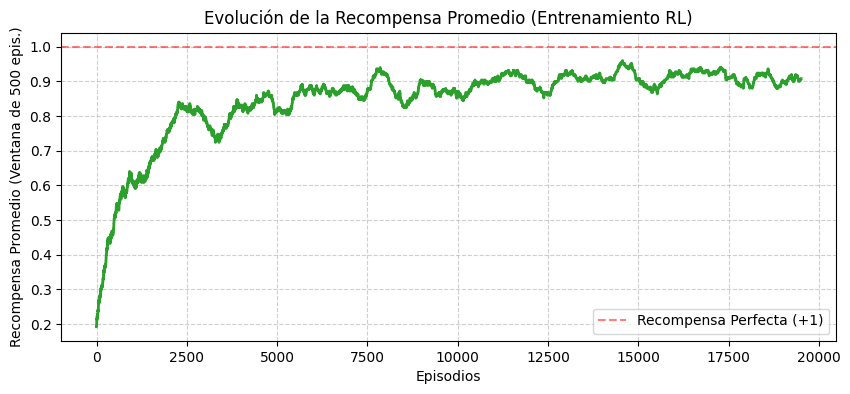

Precisión en conjunto de Test: 97.78%


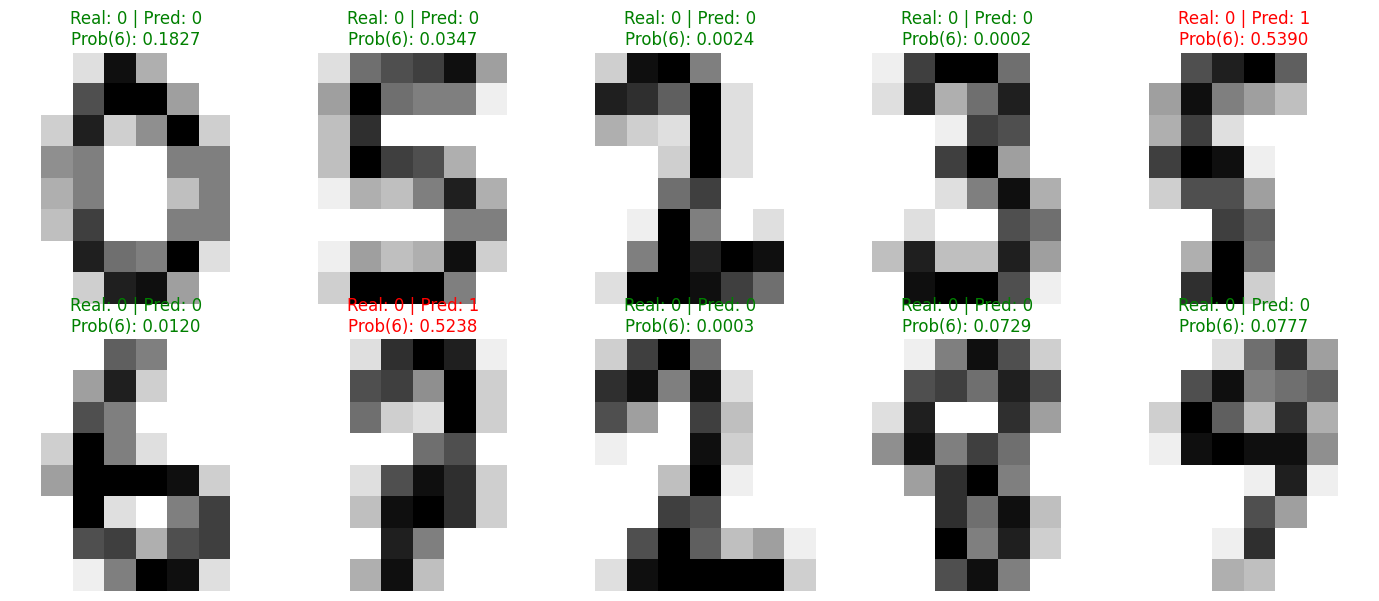

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# ==========================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
digits = load_digits()
X = digits.data / 16.0  # Normalización [0, 1]
y_binary = (digits.target == 6).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

# ==========================================
# 2. ENTORNO BALANCEADO DE RL
# ==========================================
class MNISTBinaryEnv:
    def __init__(self, X_data, y_data):
        self.X = X_data
        self.y = y_data
        self.indices_6 = np.where(y_data == 1)[0]
        self.indices_not_6 = np.where(y_data == 0)[0]

    def reset(self, balanced=True):
        # 50% de probabilidad de mostrar un 6 para evitar el sesgo
        if balanced and np.random.rand() < 0.5:
            self.current_idx = np.random.choice(self.indices_6)
        else:
            self.current_idx = np.random.choice(self.indices_not_6)

        return self.X[self.current_idx]

    def step(self, action):
        target = self.y[self.current_idx]
        reward = 1.0 if action == target else -1.0
        return reward, True, target

# ==========================================
# 3. AGENTE CON INICIALIZACIÓN XAVIER
# ==========================================
class RLAgent:
    def __init__(self, input_dim, lr=0.005):
        # Inicialización Xavier/Glorot para evitar saturación de la sigmoide
        self.weights = np.random.randn(input_dim) * np.sqrt(2.0 / input_dim)
        self.bias = 0.0
        self.lr = lr

    def sigmoid(self, z):
        z_clipped = np.clip(z, -10, 10)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def get_action_prob(self, state):
        z = np.dot(state, self.weights) + self.bias
        return self.sigmoid(z)

    def select_action(self, state):
        prob_is_six = self.get_action_prob(state)
        action = 1 if np.random.rand() < prob_is_six else 0
        return action, prob_is_six

    def train_step(self, state, action, reward, prob):
        grad_z = (1.0 - prob) if action == 1 else (-prob)

        # Clip de gradiente para estabilidad
        dW = np.clip(grad_z * state * reward, -1.0, 1.0)
        db = np.clip(grad_z * reward, -1.0, 1.0)

        self.weights += self.lr * dW
        self.bias += self.lr * db

# ==========================================
# 4. BUCLE DE ENTRENAMIENTO
# ==========================================
env = MNISTBinaryEnv(X_train, y_train)
agent = RLAgent(input_dim=X_train.shape[1], lr=0.005)

episodes = 20000
history_rewards = []

for episode in range(episodes):
    state = env.reset(balanced=True)
    action, prob = agent.select_action(state)
    reward, done, _ = env.step(action)

    agent.train_step(state, action, reward, prob)
    history_rewards.append(reward)

# ==========================================
# 5. GRÁFICO DE EVOLUCIÓN DE LA RECOMPENSA
# ==========================================
window = 500  # Ventana para promediar el ruido
smoothed_rewards = np.convolve(history_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed_rewards, color='#2ca02c', linewidth=2)
plt.title("Evolución de la Recompensa Promedio (Entrenamiento RL)", fontsize=12)
plt.xlabel("Episodios")
plt.ylabel("Recompensa Promedio (Ventana de 500 epis.)")
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label="Recompensa Perfecta (+1)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# ==========================================
# 6. EVALUACIÓN Y PRECISIÓN FINAL
# ==========================================
correct_predictions = 0

for i in range(len(X_test)):
    state = X_test[i]
    target = y_test[i]
    prob_is_six = agent.get_action_prob(state)
    predicted_action = 1 if prob_is_six >= 0.5 else 0
    if predicted_action == target:
        correct_predictions += 1

accuracy = (correct_predictions / len(X_test)) * 100
print(f"Precisión en conjunto de Test: {accuracy:.2f}%")

# ==========================================
# 7. MUESTRA DE RESULTADOS VISUALES
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
sample_indices = np.random.choice(len(X_test), 10, replace=False)

for idx, ax in enumerate(axes):
    sample_idx = sample_indices[idx]
    image = digits.images[int(len(X_train) + sample_idx)]
    state = X_test[sample_idx]
    target = y_test[sample_idx]

    prob = agent.get_action_prob(state)
    pred = 1 if prob >= 0.5 else 0

    ax.imshow(image, cmap='gray_r')
    title_color = 'green' if pred == target else 'red'

    prob_str = f"{prob:.2e}" if prob < 0.0001 else f"{prob:.4f}"
    ax.set_title(f"Real: {target} | Pred: {pred}\nProb(6): {prob_str}", color=title_color)
    ax.axis('off')

plt.tight_layout()
plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000
Características por imagen (28x28): 784


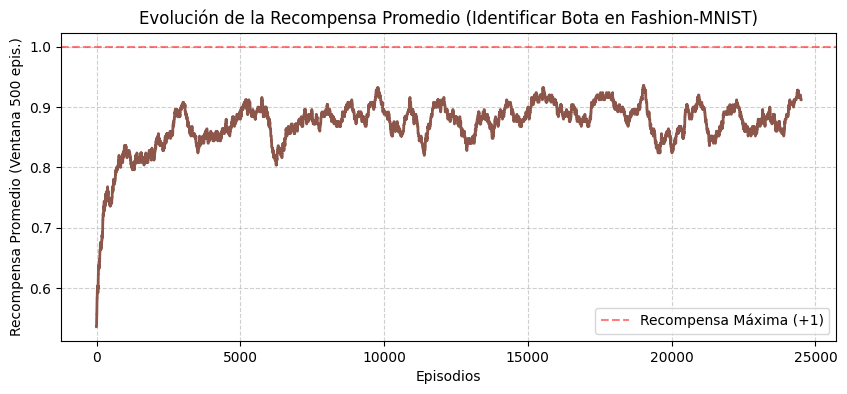

Precisión final en el conjunto de Prueba: 92.78%


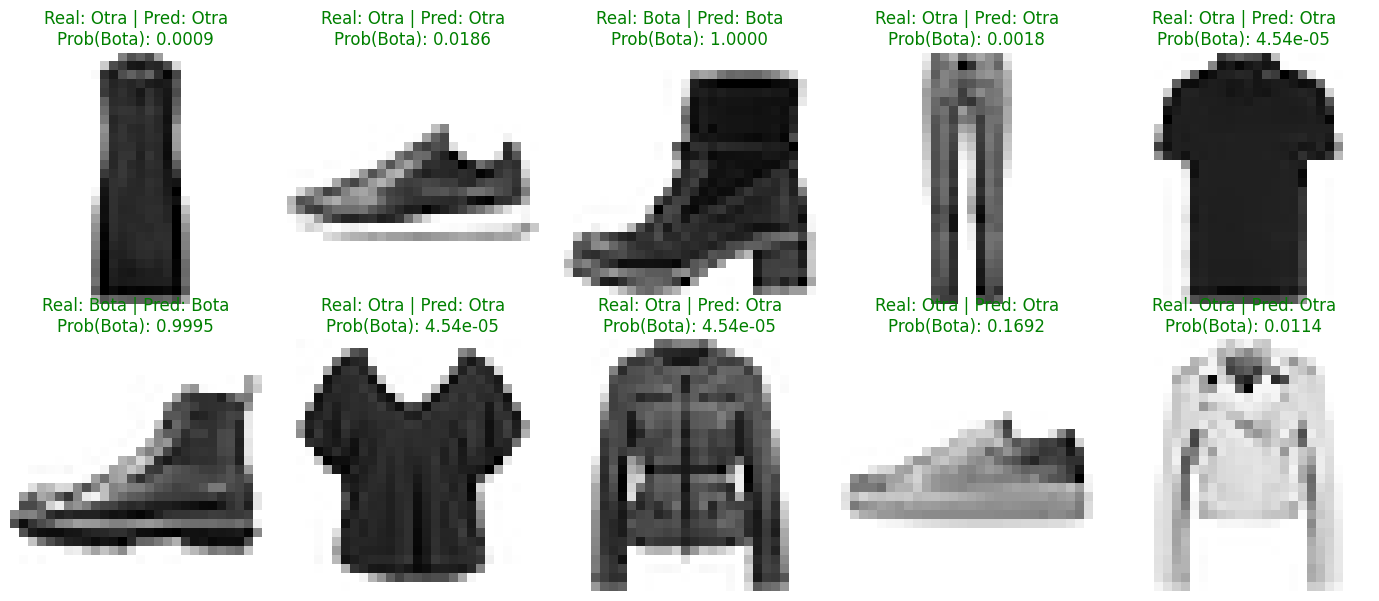

In [6]:
# ==========================================
# 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# ==========================================
# 2. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
# Cargamos Fashion-MNIST directamente
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = fashion_mnist.load_data()

# Aplanamos (28x28 -> 784) y normalizamos los valores de píxel a [0, 1]
X_train = X_train_orig.reshape(-1, 28 * 28) / 255.0
X_test = X_test_orig.reshape(-1, 28 * 28) / 255.0

# Etiqueta objetivo: 9 = Ankle Boot (Botín / Bota)
TARGET_CLASS = 9

y_train = (y_train_orig == TARGET_CLASS).astype(int)
y_test = (y_test_orig == TARGET_CLASS).astype(int)

print(f"Imágenes de entrenamiento: {X_train.shape[0]}")
print(f"Imágenes de prueba: {X_test.shape[0]}")
print(f"Características por imagen (28x28): {X_train.shape[1]}")

# ==========================================
# 3. ENTORNO DE RL (Fashion MNIST Environment)
# ==========================================
class FashionBinaryEnv:
    def __init__(self, X_data, y_data):
        self.X = X_data
        self.y = y_data
        self.indices_target = np.where(y_data == 1)[0]
        self.indices_not_target = np.where(y_data == 0)[0]

    def reset(self, balanced=True):
        # Muestreo balanceado (50% bota, 50% otras prendas)
        if balanced and np.random.rand() < 0.5:
            self.current_idx = np.random.choice(self.indices_target)
        else:
            self.current_idx = np.random.choice(self.indices_not_target)

        return self.X[self.current_idx]

    def step(self, action):
        target = self.y[self.current_idx]
        reward = 1.0 if action == target else -1.0
        return reward, True, target

# ==========================================
# 4. AGENTE DE RL (Policy Gradient / REINFORCE)
# ==========================================
class RLAgent:
    def __init__(self, input_dim, lr=0.002):
        # Inicialización Xavier/Glorot adaptada a 784 entradas
        self.weights = np.random.randn(input_dim) * np.sqrt(2.0 / input_dim)
        self.bias = 0.0
        self.lr = lr

    def sigmoid(self, z):
        z_clipped = np.clip(z, -10, 10)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def get_action_prob(self, state):
        z = np.dot(state, self.weights) + self.bias
        return self.sigmoid(z)

    def select_action(self, state):
        prob_is_boot = self.get_action_prob(state)
        action = 1 if np.random.rand() < prob_is_boot else 0
        return action, prob_is_boot

    def train_step(self, state, action, reward, prob):
        grad_z = (1.0 - prob) if action == 1 else (-prob)

        # Clipping de gradientes para garantizar convergencia
        dW = np.clip(grad_z * state * reward, -1.0, 1.0)
        db = np.clip(grad_z * reward, -1.0, 1.0)

        self.weights += self.lr * dW
        self.bias += self.lr * db

# ==========================================
# 5. BUCLE DE ENTRENAMIENTO
# ==========================================
env = FashionBinaryEnv(X_train, y_train)
agent = RLAgent(input_dim=X_train.shape[1], lr=0.002)

episodes = 25000
history_rewards = []

for episode in range(episodes):
    state = env.reset(balanced=True)
    action, prob = agent.select_action(state)
    reward, done, _ = env.step(action)

    agent.train_step(state, action, reward, prob)
    history_rewards.append(reward)

# ==========================================
# 6. GRÁFICO DE EVOLUCIÓN DE LA RECOMPENSA
# ==========================================
window = 500
smoothed_rewards = np.convolve(history_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed_rewards, color='#8c564b', linewidth=2)
plt.title("Evolución de la Recompensa Promedio (Identificar Bota en Fashion-MNIST)")
plt.xlabel("Episodios")
plt.ylabel("Recompensa Promedio (Ventana 500 epis.)")
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label="Recompensa Máxima (+1)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# ==========================================
# 7. EVALUACIÓN DE PRECISIÓN EN TEST SET
# ==========================================
correct_predictions = 0

for i in range(len(X_test)):
    state = X_test[i]
    target = y_test[i]
    prob_is_boot = agent.get_action_prob(state)
    predicted_action = 1 if prob_is_boot >= 0.5 else 0
    if predicted_action == target:
        correct_predictions += 1

accuracy = (correct_predictions / len(X_test)) * 100
print(f"Precisión final en el conjunto de Prueba: {accuracy:.2f}%")

# ==========================================
# 8. VISUALIZACIÓN DE RESULTADOS
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
sample_indices = np.random.choice(len(X_test), 10, replace=False)

for idx, ax in enumerate(axes):
    sample_idx = sample_indices[idx]
    image = X_test_orig[sample_idx]  # Matriz original 28x28 para graficar
    state = X_test[sample_idx]
    target = y_test[sample_idx]

    prob = agent.get_action_prob(state)
    pred = 1 if prob >= 0.5 else 0

    ax.imshow(image, cmap='gray_r')
    title_color = 'green' if pred == target else 'red'

    prob_str = f"{prob:.2e}" if prob < 0.0001 else f"{prob:.4f}"
    label_txt = "Bota" if target == 1 else "Otra"
    pred_txt = "Bota" if pred == 1 else "Otra"

    ax.set_title(f"Real: {label_txt} | Pred: {pred_txt}\nProb(Bota): {prob_str}", color=title_color)
    ax.axis('off')

plt.tight_layout()
plt.show()